In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
from pathlib import Path

DATA = Path("../data/processed")

fund_master = pd.read_csv(DATA/"clean_fund_master.csv")
nav = pd.read_csv(DATA/"clean_nav_history.csv")
aum = pd.read_csv(DATA/"clean_aum_by_fund_house.csv")
sip = pd.read_csv(DATA/"clean_monthly_sip_inflows.csv")
category = pd.read_csv(DATA/"clean_category_inflows.csv")
folio = pd.read_csv(DATA/"clean_industry_folio_count.csv")
performance = pd.read_csv(DATA/"clean_scheme_performance.csv")
transactions = pd.read_csv(DATA/"clean_investor_transactions.csv")
portfolio = pd.read_csv(DATA/"clean_portfolio_holdings.csv")
benchmark = pd.read_csv(DATA/"clean_benchmark_indices.csv")

print("All Day 3 datasets loaded successfully")

All Day 3 datasets loaded successfully


In [3]:
nav['date'] = pd.to_datetime(nav['date'])

print(nav.head())
print(nav.dtypes)

        date  amfi_code       nav  daily_return
0 2022-01-03     100016  520.4608      0.000000
1 2022-01-04     100016  515.0971     -0.010306
2 2022-01-05     100016  521.7239      0.012865
3 2022-01-06     100016  515.7880     -0.011377
4 2022-01-07     100016  515.1639     -0.001210
date            datetime64[us]
amfi_code                int64
nav                    float64
daily_return           float64
dtype: object


In [4]:
print(nav.columns.tolist())

['date', 'amfi_code', 'nav', 'daily_return']


In [ ]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend for All 40 Mutual Fund Schemes (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Corrections",
    annotation_position="top right"
)

fig.show()

In [6]:
fig.write_html("../reports/nav_trend_all_schemes.html")
print("Chart saved successfully")

Chart saved successfully


In [7]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


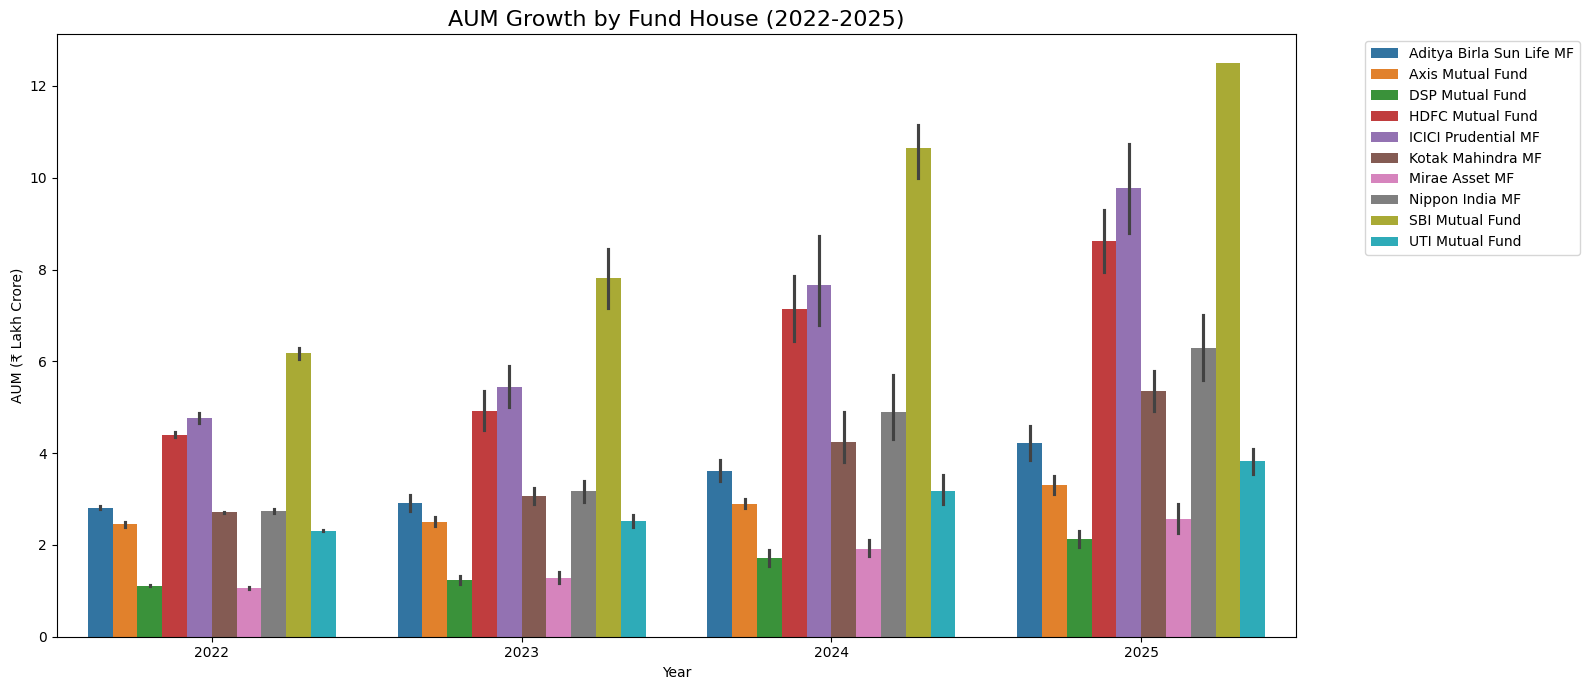

In [8]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(16, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("../reports/aum_growth_by_fund_house.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [10]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.write_html("../reports/sip_inflow_trend.html")
fig.show()

In [11]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


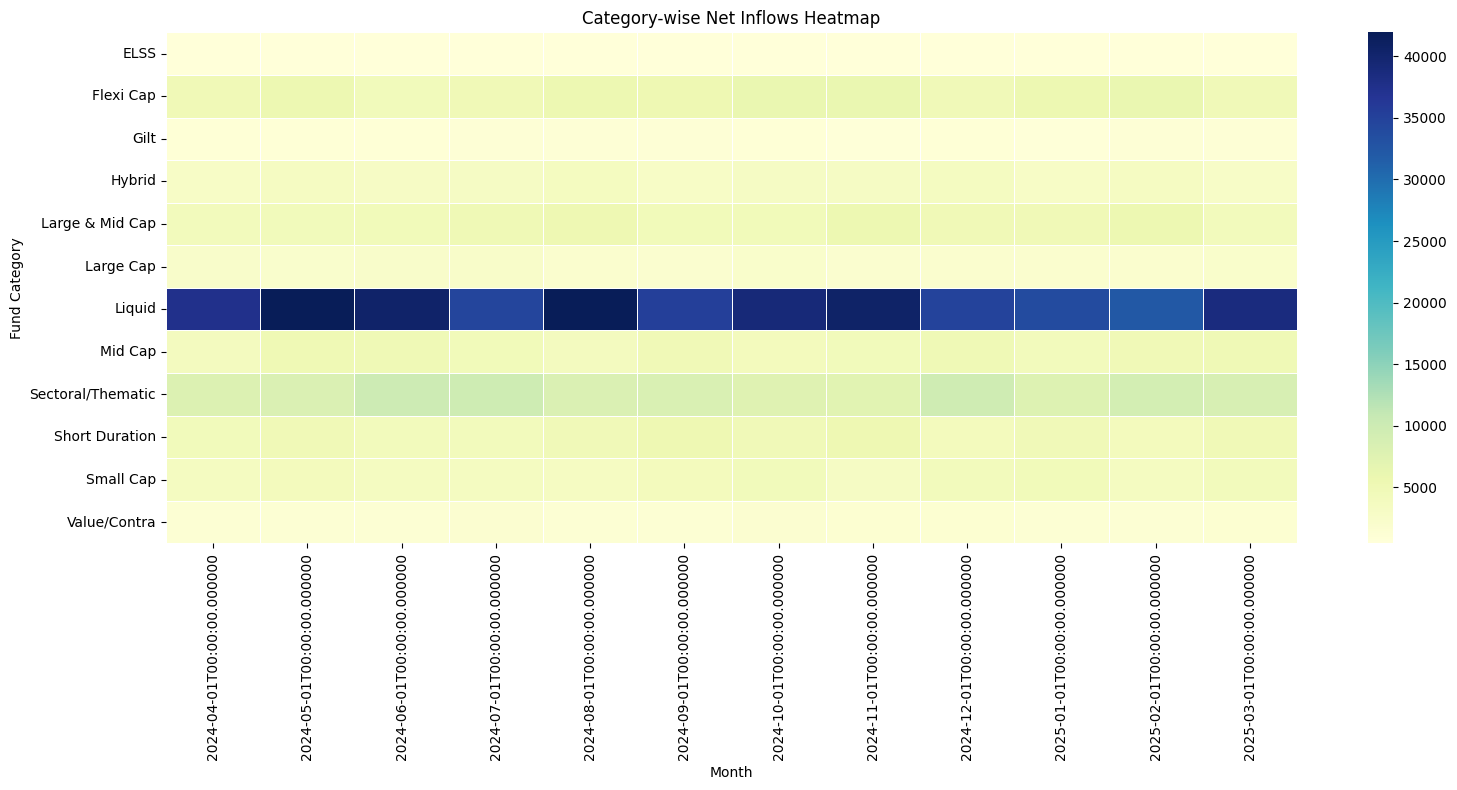

In [12]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
print(transactions.columns.tolist())

['transaction_id', 'investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


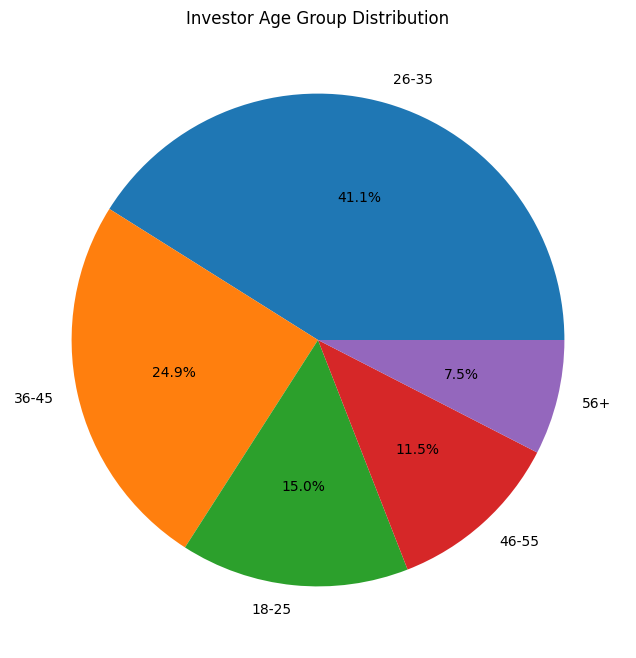

In [14]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

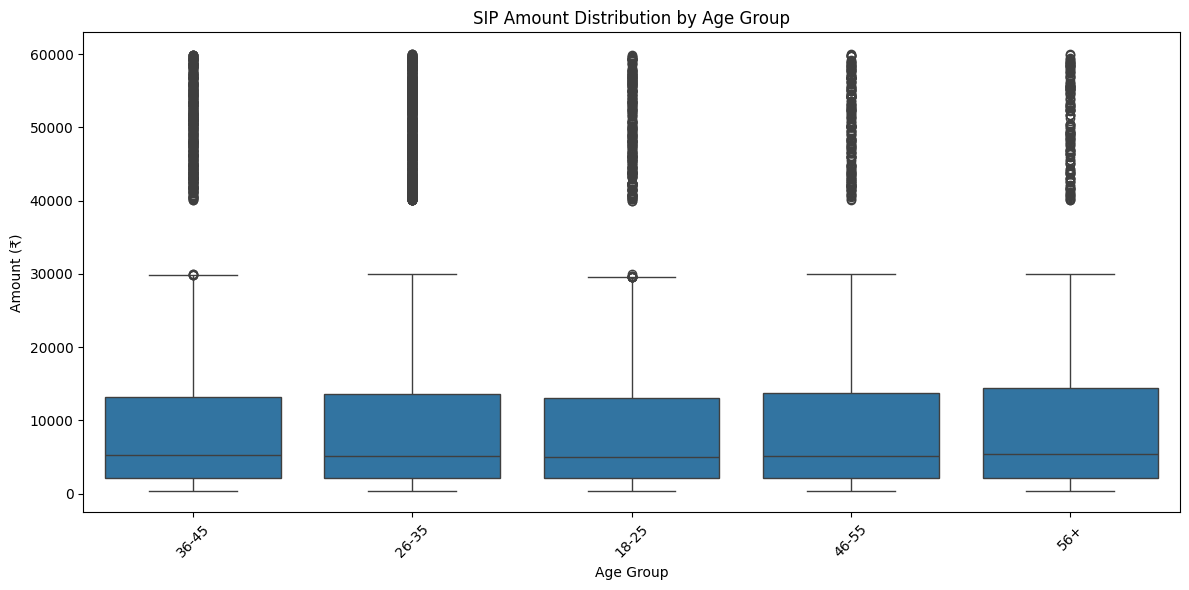

In [15]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

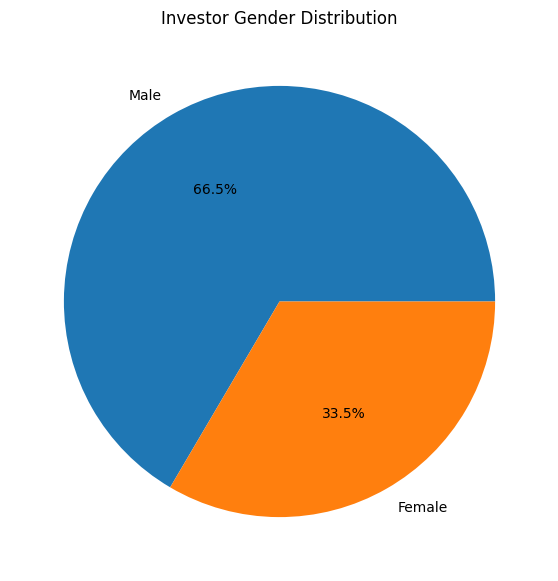

In [16]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

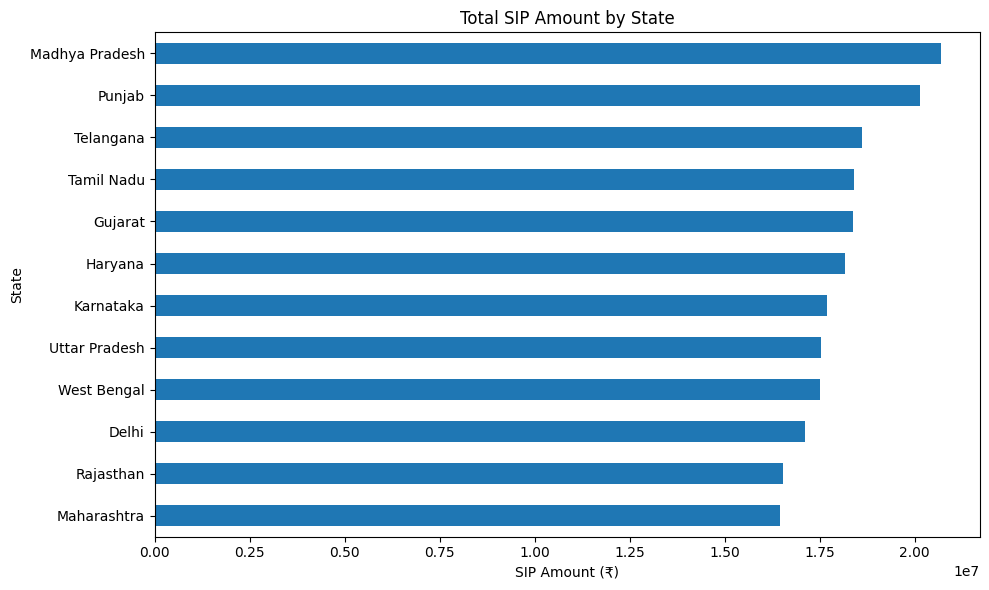

In [17]:
state_sip = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/sip_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

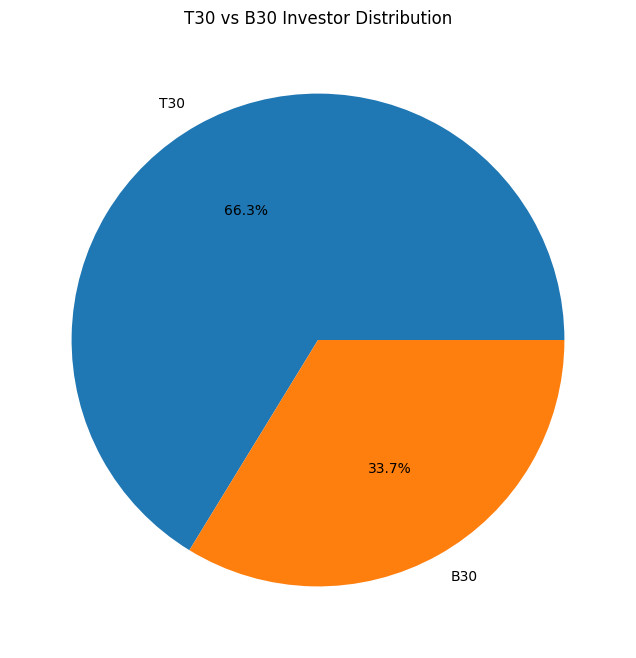

In [18]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


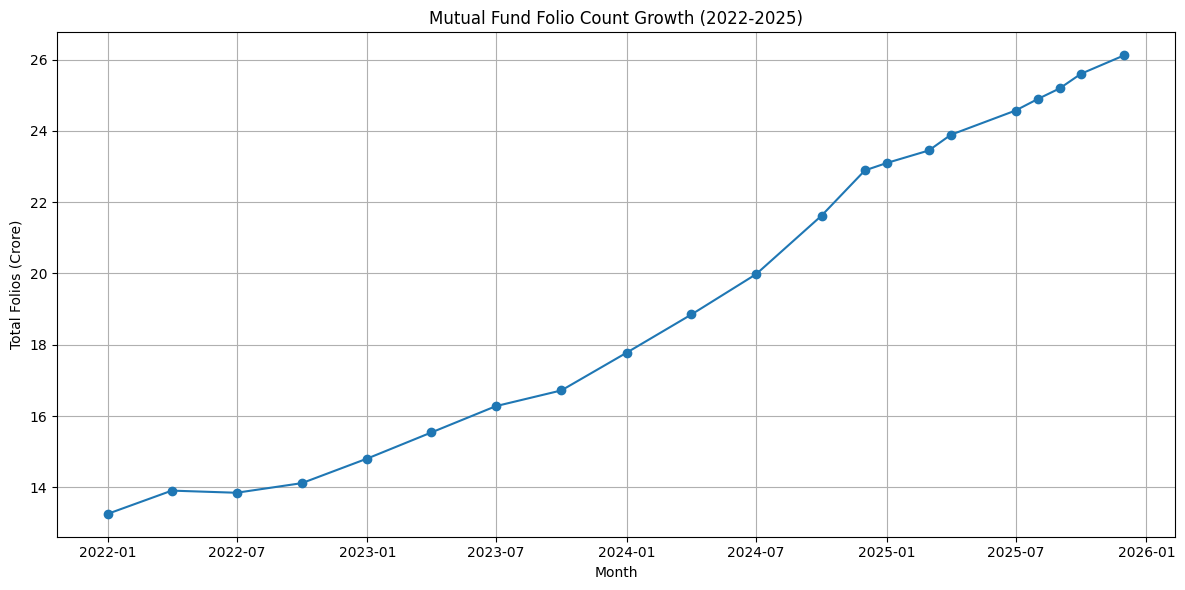

In [22]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../reports/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


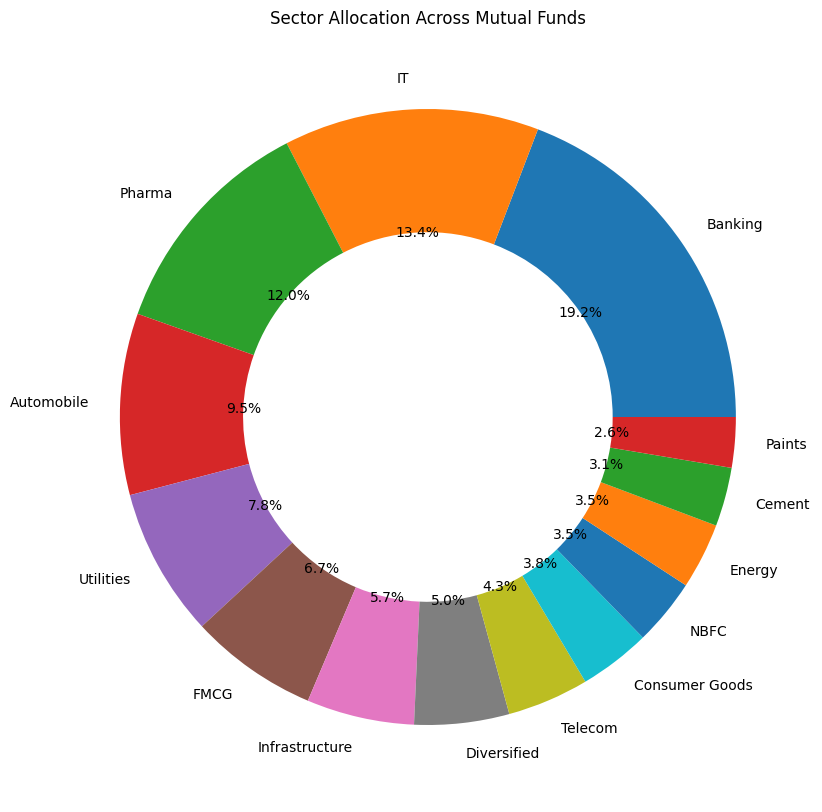

In [24]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Mutual Funds")

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

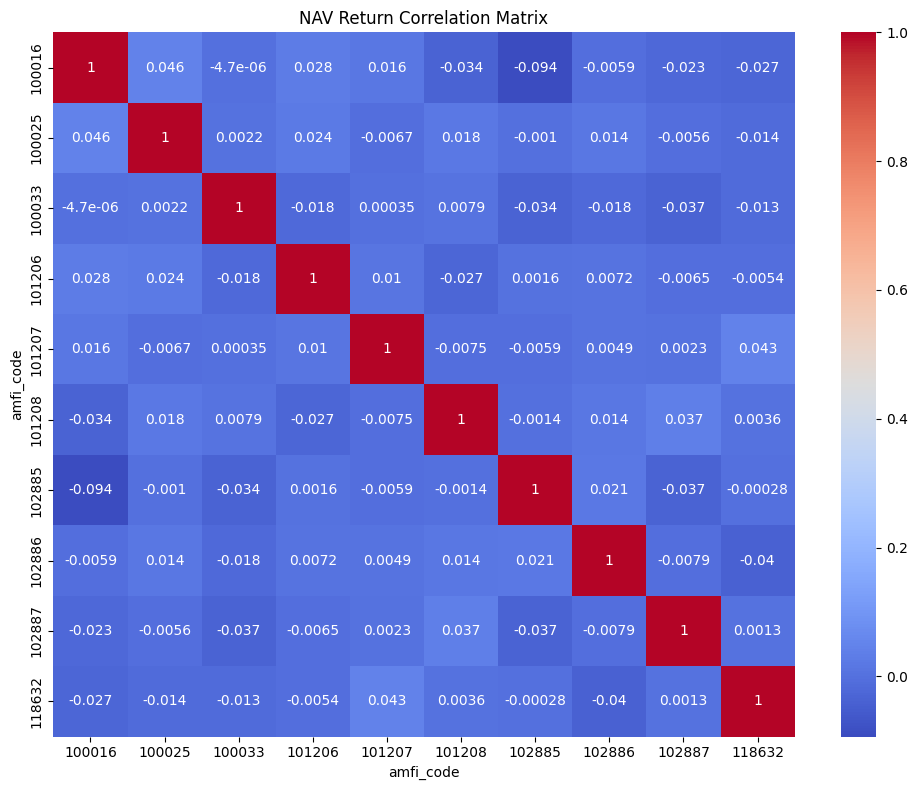

In [25]:
top10_codes = nav["amfi_code"].unique()[:10]

corr_df = nav[
    nav["amfi_code"].isin(top10_codes)
]

corr_matrix = corr_df.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Key EDA Findings

1. SBI Mutual Fund maintains the highest AUM among all fund houses.

2. SIP inflows showed a strong upward trend from 2022 to 2025.

3. December 2025 recorded the highest SIP inflow of ₹31,002 crore.

4. Liquid funds attracted the largest category-wise inflows.

5. Mutual fund folio count nearly doubled during the study period.

6. SIP remains the dominant investment transaction type.

7. Investor participation is highest in the 25–34 age group.

8. Tier-1 cities contribute the majority of mutual fund transactions.

9. Financial Services and Technology sectors account for a significant share of portfolio allocation.

10. Several equity schemes exhibit strong positive return correlations, indicating similar market exposure.